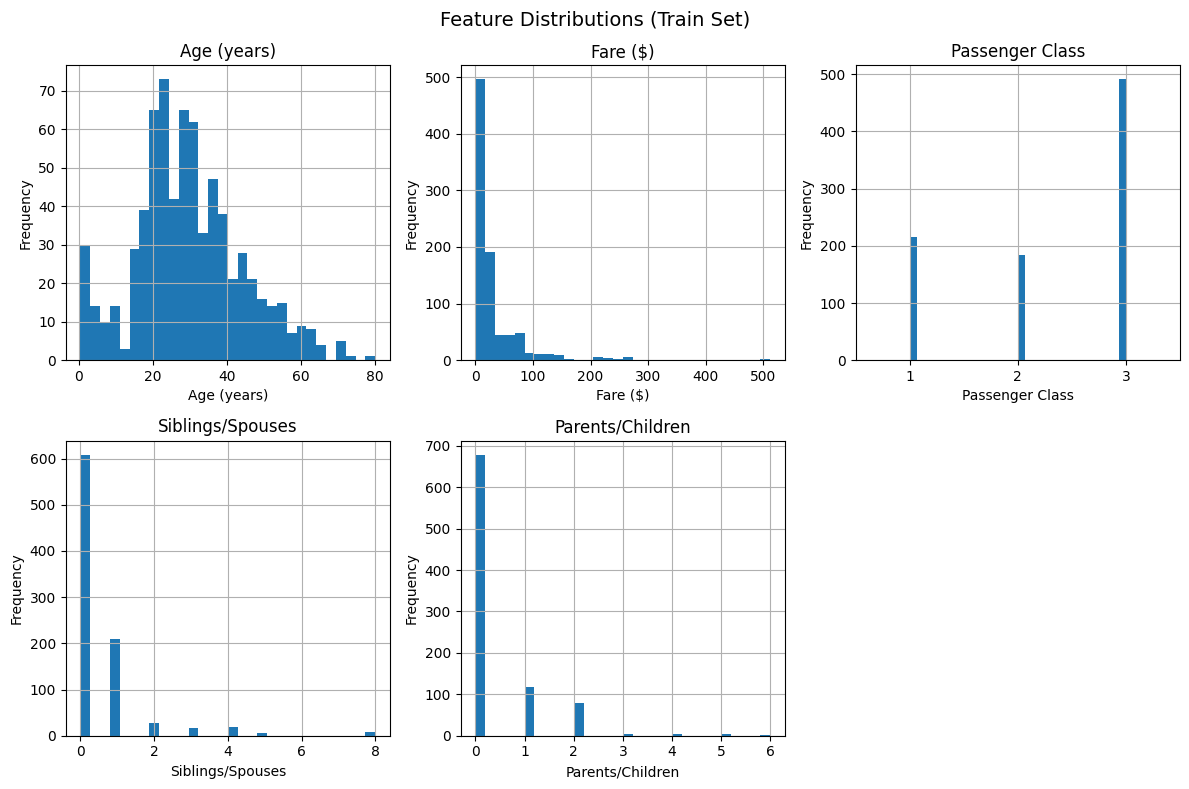

Survival rate by Sex:
 Sex
female    0.742038
male      0.188908
Name: Survived, dtype: float64

Survival rate by Class:
 Pclass
1    0.629630
2    0.472826
3    0.242363
Name: Survived, dtype: float64


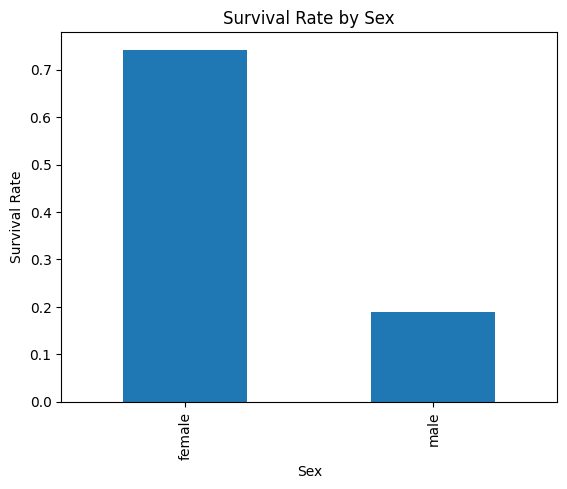

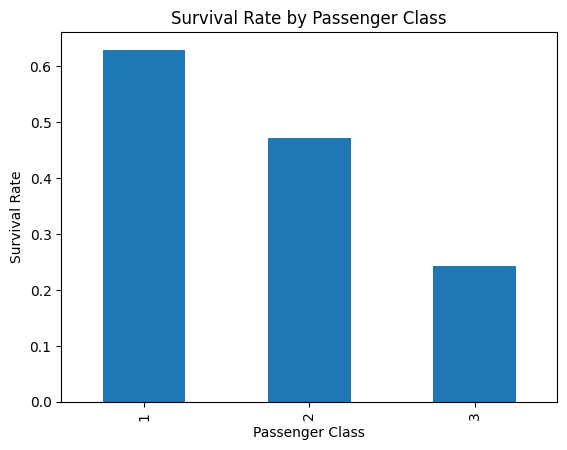


Test Set Predictions (first 10 passengers):
Predictions: [0 1 0 0 1 0 1 0 1 0]
Total test predictions made: 418
  0 = Did Not Survive, 1 = Survived

Prediction Summary:
  Predicted Did Not Survive (0): 262
  Predicted Survived (1): 156
  Survival rate in test predictions: 37.3%

Validation Accuracy: 0.7933
SURVIVAL RATE BY SEX AND PASSENGER CLASS
               Total Passengers  Survivors  Survival Rate
Sex    Pclass                                            
female 1                     94         91          0.968
       2                     76         70          0.921
       3                    144         72          0.500
male   1                    122         45          0.369
       2                    108         17          0.157
       3                    347         47          0.135


SURVIVOR VS NON-SURVIVOR COMPARISON
                   Age          Fare        Pclass       
                  mean median   mean median   mean median
Did Not Survive  30.63   28.0  2

In [5]:
from pathlib import Path
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.svm import SVC
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import accuracy_score
from sklearn.metrics import classification_report

#function to load data
def load_titanic_data(csv_path="train.csv"):
    csv_path = Path(csv_path)
    if not csv_path.is_file():
        raise FileNotFoundError(
            f"Couldn't find {csv_path}. Put train.csv there or update the path."
        )
    return pd.read_csv(csv_path)

# Load both datasets
titanic = load_titanic_data("train.csv")
titanic_test = load_titanic_data("test.csv")

# Plot datasets
fig, axes = plt.subplots(2, 3, figsize=(12, 8))
axes = axes.flatten()

#define features to plot and their labels
features_to_plot = ["Age", "Fare", "Pclass", "SibSp", "Parch"]
feature_labels = {
    "Age": "Age (years)",
    "Fare": "Fare ($)",
    "Pclass": "Passenger Class",
    "SibSp": "Siblings/Spouses",
    "Parch": "Parents/Children"
}

# Plot histograms for each feature
for idx, feature in enumerate(features_to_plot):
    titanic[feature].hist(ax=axes[idx], bins=30)
    axes[idx].set_title(feature_labels[feature], fontsize=12)
    axes[idx].set_xlabel(feature_labels[feature])
    axes[idx].set_ylabel("Frequency")
    if feature == "Pclass":
        axes[idx].set_xticks([1, 2, 3])
        axes[idx].set_xlim(0.5, 3.5)

axes[5].remove()  # Remove the extra subplot
fig.suptitle("Feature Distributions (Train Set)", fontsize=14)
plt.tight_layout()
plt.show()

# Group survival rate data by sex and class and plot
survival_by_sex = titanic.groupby("Sex")["Survived"].mean()
survival_by_class = titanic.groupby("Pclass")["Survived"].mean()

print("Survival rate by Sex:\n", survival_by_sex)
print("\nSurvival rate by Class:\n", survival_by_class)


survival_by_sex.plot(kind="bar")
plt.ylabel("Survival Rate")
plt.title("Survival Rate by Sex")
plt.show()

survival_by_class.plot(kind="bar")
plt.ylabel("Survival Rate")
plt.xlabel("Passenger Class")
plt.title("Survival Rate by Passenger Class")
plt.show()


#prepare data for modeling
features = ["Pclass", "Sex", "Age", "Fare"]
X = titanic[features].copy()
y = titanic["Survived"]
X_final_test = titanic_test[features].copy()

# ETL case: Handle missing values and encode categorical variables
age_median = X["Age"].median()
X["Age"] = X["Age"].fillna(age_median)
X_final_test["Age"] = X_final_test["Age"].fillna(age_median)

fare_median = X["Fare"].median()
X["Fare"] = X["Fare"].fillna(fare_median)
X_final_test["Fare"] = X_final_test["Fare"].fillna(fare_median)

sex_map = {"male": 0, "female": 1}
X["Sex"] = X["Sex"].map(sex_map)
X_final_test["Sex"] = X_final_test["Sex"].map(sex_map)

sex_mode = X["Sex"].mode()[0]
X["Sex"] = X["Sex"].fillna(sex_mode)
X_final_test["Sex"] = X_final_test["Sex"].fillna(sex_mode)

# splitting data into training and validation sets

X_train, X_val, y_train, y_val = train_test_split(
    X, y, test_size=0.2, random_state=42
)

# model training and evaluation


scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_val_scaled = scaler.transform(X_val)
X_final_test_scaled = scaler.transform(X_final_test)

model = SVC(kernel='rbf', random_state=42, class_weight='balanced')
model.fit(X_train_scaled, y_train)

# calculate accuracy on validation set

y_pred = model.predict(X_val_scaled)
accuracy = accuracy_score(y_val, y_pred)
accuracy

# predict data based on test set and show results
test_predictions = model.predict(X_final_test_scaled)
print(f"\nTest Set Predictions (first 10 passengers):")
print(f"Predictions: {test_predictions[:10]}")
print(f"Total test predictions made: {len(test_predictions)}")
print(f"  0 = Did Not Survive, 1 = Survived")

# Show distribution of predictions
print(f"\nPrediction Summary:")
print(f"  Predicted Did Not Survive (0): {(test_predictions == 0).sum()}")
print(f"  Predicted Survived (1): {(test_predictions == 1).sum()}")
print(f"  Survival rate in test predictions: {test_predictions.mean():.1%}")

print(f"\nValidation Accuracy: {accuracy:.4f}")

# Survival Rate by Sex and Passenger Class
print("SURVIVAL RATE BY SEX AND PASSENGER CLASS")
print("="*60)
survival_by_sex_class = titanic.groupby(['Sex', 'Pclass'])['Survived'].agg(['count', 'sum', 'mean']).round(3)
survival_by_sex_class.columns = ['Total Passengers', 'Survivors', 'Survival Rate']
print(survival_by_sex_class)

# Survivor vs Non-Survivor Comparison Table and Key Findings
print("\n\nSURVIVOR VS NON-SURVIVOR COMPARISON")
print("="*60)
survivor_comparison = titanic.groupby('Survived')[['Age', 'Fare', 'Pclass']].agg(['mean', 'median'])
survivor_comparison.index = ['Did Not Survive', 'Survived']
print(survivor_comparison.round(2))

print("\nKey Findings:")
print(f"  • Average Age - Survived: {titanic[titanic['Survived']==1]['Age'].mean():.1f} years, Did Not Survive: {titanic[titanic['Survived']==0]['Age'].mean():.1f} years")
print(f"  • Average Fare - Survived: ${titanic[titanic['Survived']==1]['Fare'].mean():.2f}, Did Not Survive: ${titanic[titanic['Survived']==0]['Fare'].mean():.2f}")
print(f"  • Avg Pclass - Survived: {titanic[titanic['Survived']==1]['Pclass'].mean():.2f}, Did Not Survive: {titanic[titanic['Survived']==0]['Pclass'].mean():.2f}")
print(f"    (Lower class number = higher socioeconomic status)")

# Classification Report
print("\n" + "="*50)
print("CLASSIFICATION REPORT")
print("="*50)
report = classification_report(y_val, y_pred, target_names=['Did Not Survive', 'Survived'])
print(report)